In [ ]:
using QuantumToolbox
using LinearAlgebra

In [ ]:
X = [0.0 1.0; 1.0 0.0]
Y = [0.0 1.0*-im; 1.0*im 0.0]
Z = [1.0 0.0; 0.0 -1.0]
su2 = [1im*X, 1im*Y, 1im*Z]
coeffs = [1.,2.,3.]
exponent = sum(coeffs.*su2)
U = exp(exponent)

if U*U' ≈ I
    return true
else 
    return false
end

In [ ]:
coeffs2 = [1.0, 2.0+ 1im, 3.0]
exponent = sum(coeffs2.*su2) 
U = exp(exponent)
if U*U' ≈ I
    return true
else 
    return false
end

# DRAG vs GAUSSIAN vs GRAPE

In [2]:
using Piccolo
using CairoMakie

In [3]:
const Levels = 3
const Delta = 0.2
const Drive_bound = 0.5

sys = TransmonSystem(drive_bounds = [Drive_bound, Drive_bound], levels = Levels, δ = Delta)

U_goal = EmbeddedOperator(:X, sys) #X gate acting on |0>,|1> computational subspace

#intgrate a fucntion over [0,tg] with trapezoid rule used to claobrate the pulse area 
function trapezoid(f, tg, n=2000)
    ts = range(0, tg; length = n)
    ys = f.(ts)
    dt = tg/(n-1)
    return dt * (sum(ys)- 0.5*(ys[1] + ys[end]))
end

function gaussian_pulse(tg; sigma_frac = 0.5) # are aclaibrates the mplitude to pi(for X Gate)
    sigma = sigma_frac*tg
    shape(t) = exp(-(t-tg/2)^2/(2*sigma^2))
    area_unit = trapezoid(shape, tg)
    A = pi/area_unit
    return GaussianPulse([A,0.0],sigma,tg;center = tg/2)
end

function drag_pulse(tg,Δ;sigma_frac = 0.5, beta = 1.0)
    sigma = sigma_frac*tg
    shape(t) = exp(-(t-tg/2)^2/(2*sigma^2))
    dshape(t) = -(t-tg/2)/sigma^2*shape(t)
    area_unit = trapezoid(shape,tg)
    A = pi/area_unit

    f = t -> begin
        if t< 0 || t>tg
            return [0.0,0.0]
        end
        Ωx = A *shape(t)
        Ωy = -(beta/Δ)*A*dshape(t)
        return [Ωx,Ωy]
    end
    return FunctionPulse(f,tg,2)
end

function gate_error(pulse,tg)
    qtraj = UnitaryTrajectory(sys,pulse, U_goal)
    out = rollout(qtraj)
    return 1-fidelity(out)
end

function optimized_error(tg, Δ; N =60,max_iter =150)
    drag = drag_pulse(tg, Δ)
    times = collect(range(0,tg,length =N))
    ctrl = hcat([drag(t) for t in times]...)
    
    qtraj = qtraj = UnitaryTrajectory(sys,ZeroOrderPulse(ctrl, times),U_goal)
    opts = PiccoloOptions(display = :silent)
    qcp = SmoothPulseProblem(qtraj,N; Q =100.0, R = 1e-3, piccolo_options = opts)
    solve!(qcp; max_iter =max_iter, print_level = 1, eval_hessian = false)
    return 1 - fidelity(qcp)
end



optimized_error (generic function with 1 method)

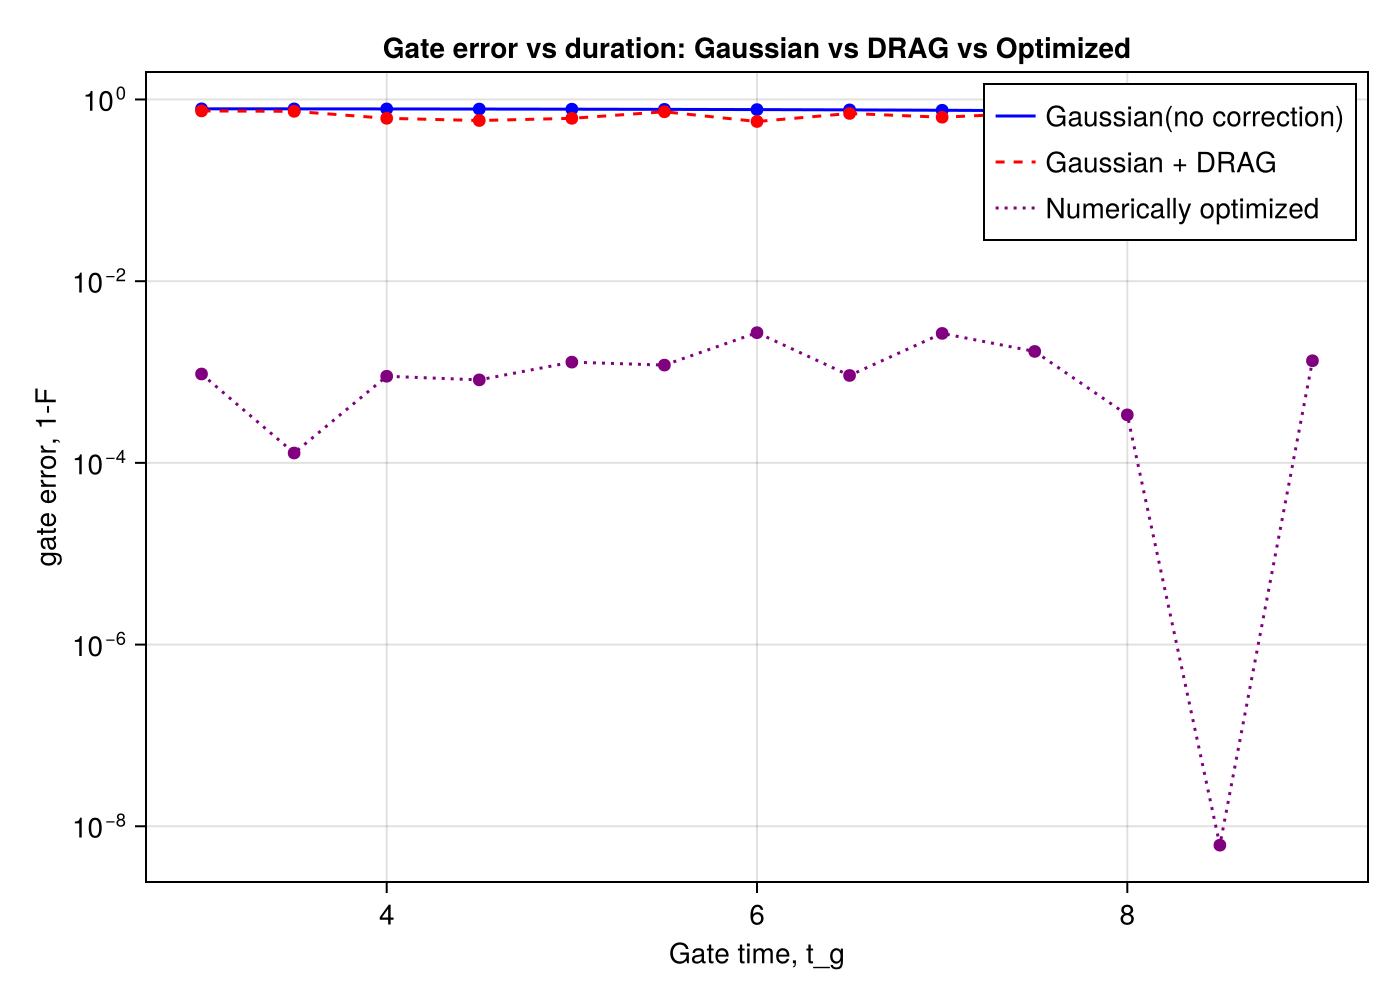

┌ Warning: Trajectory has timestep variable :Δt but no bounds on it.
│ Adding default lower bound of 0 to prevent negative timesteps.
│ 
│ Recommended: Add explicit bounds when creating the trajectory:
│   NamedTrajectory(...; Δt_bounds=(min, max))
│ Example:
│   NamedTrajectory(qtraj, N; Δt_bounds=(1e-3, 0.5))
│ 
│ Or use timesteps_all_equal=true in problem options to fix timesteps.
└ @ DirectTrajOpt.Problems /Users/jettajb1/.julia/packages/DirectTrajOpt/VOKy2/src/problems.jl:66



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Saved


In [4]:
gate_times = collect(range(3.0,9.0,length=13))
Δ = -Delta

err_gauss = Float64[]
err_drag = Float64[]
err_opt = Float64[]

for tg in gate_times
    push!(err_gauss, gate_error(gaussian_pulse(tg),tg))
    push!(err_drag, gate_error(drag_pulse(tg,Δ),tg))
    push!(err_opt, optimized_error(tg,Δ))
end

fig = Figure(size = (700,500))
ax = Axis(fig[1, 1], 
    xlabel = "Gate time, t_g", 
    ylabel = "gate error, 1-F", 
    yscale = log10, 
    title = "Gate error vs duration: Gaussian vs DRAG vs Optimized")

lines!(ax, gate_times, err_gauss, label = "Gaussian(no correction)", color =:blue)
scatter!(ax, gate_times, err_gauss, color=:blue)

lines!(ax,gate_times, err_drag, label = "Gaussian + DRAG", color =:red, linestyle = :dash)
scatter!(ax,gate_times, err_drag, color=:red)

lines!(ax,gate_times, err_opt, label = "Numerically optimized", color =:purple, linestyle = :dot)
scatter!(ax,gate_times, err_opt, color=:purple)

axislegend(ax,position = :rt, frame_visible = false)
display(fig)
#save("project1_gate_error_vs_duration",fig)
println("Saved")

# DRAG breakdown vs PWC

In [6]:
leak_indices = get_iso_vec_leakage_indices(U_goal)

8-element Vector{Int64}:
  3
  6
  9
 12
 13
 14
 16
 17

In [5]:
drag_error(tg) = begin
    qtraj = UnitaryTrajectory(sys,drag_pulse(tg,Δ),U_goal)
    1 - fidelity(rollout(qtraj))
end
function pwc_from_drag_error(tg,N =40, max_iter = 200, leakage_cost =20.0, leakage_constraint_value = 1e-3) #20
    drag = drag_pulse(tg, Δ)
    times = collect(range(0,tg,length =N))
    ctrl = hcat([drag(t) for t in times]...)
    
    qtraj = qtraj = UnitaryTrajectory(sys,ZeroOrderPulse(ctrl, times),U_goal)
    opts = PiccoloOptions(
        leakage_cost = leakage_cost,
        leakage_constraint = true,
        leakage_constraint_value = leakage_constraint_value,
        display = :silent,
    )
    qcp = SmoothPulseProblem(qtraj,N; Q =100.0, R = 1e-3, piccolo_options = opts)
    solve!(qcp; max_iter =max_iter, print_level = 1, eval_hessian = false)
    return 1 - fidelity(qcp),qcp
end

pwc_from_drag_error (generic function with 5 methods)

In [6]:
gate_times_short = collect(range(1.7,4.5,length=10))

err_drag_short = Float64[]
err_pwc = Float64[]
last_qcp = nothing

for tg in gate_times_short
    ed = drag_error(tg)
    ep, qcp = pwc_from_drag_error(tg)
    global last_qcp = qcp
    push!(err_drag_short,ed)
    push!(err_pwc,ep)
end

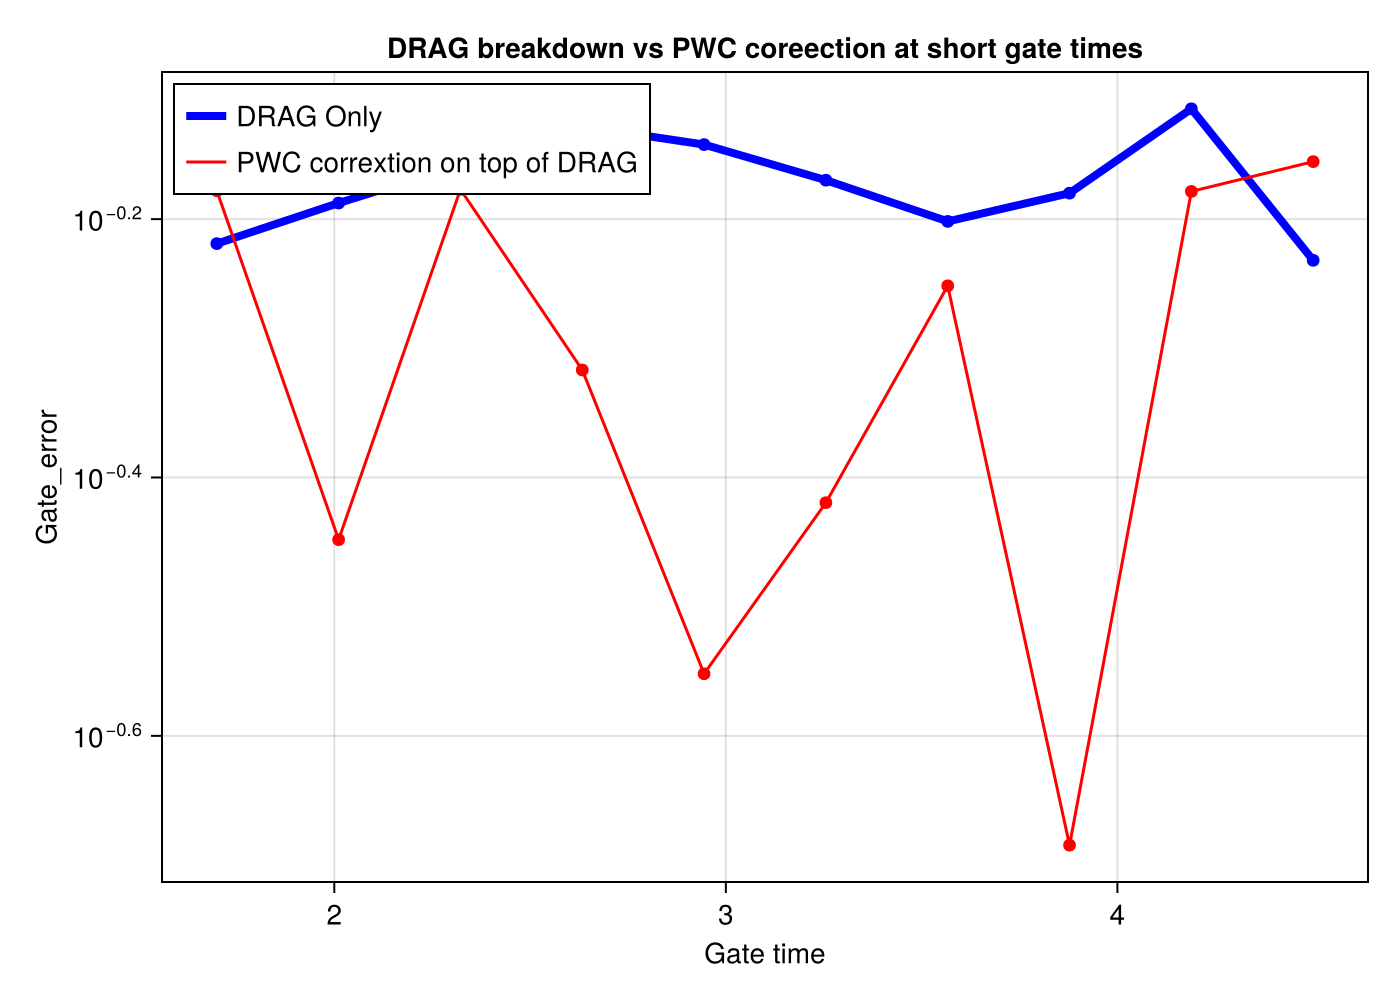

CairoMakie.Screen{IMAGE}


In [7]:
fig2 = Figure(size = (700,500))
ax2 = Axis(fig2[1,1], xlabel = "Gate time",ylabel = "Gate_error",yscale = log10, title = "DRAG breakdown vs PWC coreection at short gate times")

lines!(ax2,gate_times_short, err_drag_short,label = "DRAG Only", color = :blue, linewidth = 4.0)
scatter!(ax2, gate_times_short, err_drag_short, color =:blue)


lines!(ax2,gate_times_short, err_pwc,label = "PWC corrextion on top of DRAG", color = :red)
scatter!(ax2, gate_times_short, err_pwc, color =:red)

axislegend(ax2, position = :lt)
display(fig2)
#save("project_drag_vs_pwc_short", fig2)

In [ ]:
#=
shortest_tg = gate_times,shorts[1]

_, qcp_short = pwc_from_drag(shortest_tg)
plot_unitary_populations(get_trajexctory(qcp_short))

save("project2, snallest pwc shortest_gate", current_figure())
=#

UndefVarError: UndefVarError: `shorts` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [45]:
import Pkg
#Pkg.gc()
Pkg.develop(path="/Users/jettajb1/Work/DiffEQ/HarmonicSolvers/")

   Resolving package versions...
     Project No packages added to or removed from `~/Work/Project.toml`
    Manifest No packages added to or removed from `~/Work/Manifest.toml`


# Single vs Dual Axis Control

In [8]:
const Levels = 3
const Delta = 0.2
const Drive_bound = 0.5
const Δ_freq =-1.0*2*pi*0.4 #-0.8pi radians

sys_2d = TransmonSystem(drive_bounds = [Drive_bound, Drive_bound], levels = Levels, δ = Delta)
U_goal = EmbeddedOperator(:Y, sys) #X gate acting on |0>,|1> computational subspace




function pwc_comp_solver(tg; N = 40, max_iter = 200, use_y_axis = true)

    sys = use_y_axis ? TransmonSystem(drive_bounds = [Drive_bound, Drive_bound], levels = Levels, δ = Delta)  : TransmonSystem(drive_bounds = [Drive_bound, 0.0], levels = Levels, δ = Delta)
    drag = drag_pulse(tg, Δ_freq)
    times = collect(range(0,tg,length =N))
    ctrl=hcat([drag(t) for t in times]...)

    if !use_y_axis
        ctrl[2, :] .= 0.0
    end
    warm_pulse = ZeroOrderPulse(0.1 * randn(2, N), times)
    qtraj = UnitaryTrajectory(sys, warm_pulse,U_goal)

    opts = PiccoloOptions(
        leakage_cost = 50.0,
        leakage_constraint = true,
        leakage_constraint_value = 1e-5,
        display = :silent,
    )

    qcp = SmoothPulseProblem(qtraj, N; Q = 100.0, R = 1e-3, piccolo_options = opts)
    solve!(qcp; max_iter = max_iter, print_level = 0, eval_hessian = false)
    return 1-fidelity(qcp)
end


pwc_comp_solver (generic function with 1 method)

In [9]:
gate_times = collect(range(1.7,4.7,length =8))

err_x_only = Float64[]
err_xy = Float64[]


for tg in gate_times
    ep_x = pwc_comp_solver(tg,use_y_axis = false)
    ep_xy = pwc_comp_solver(tg,use_y_axis = true)

    push!(err_x_only,ep_x)
    push!(err_xy,ep_xy)
end



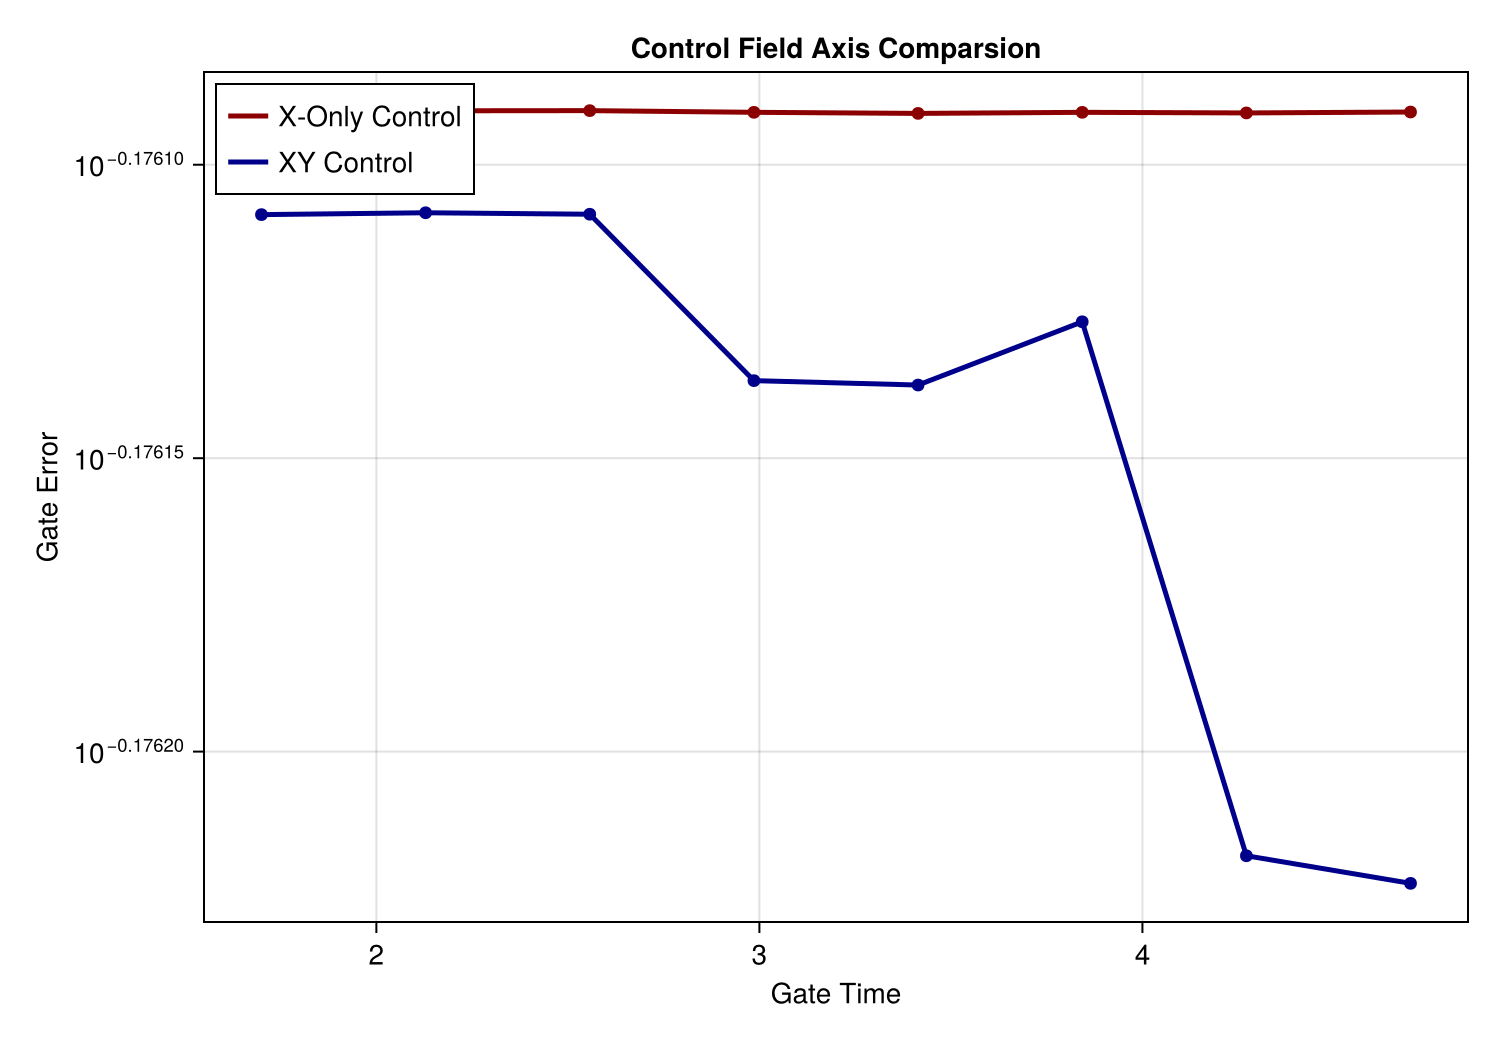

In [10]:
fig3 = Figure(size =(750,520))

ax = Axis(fig3[1,1], xlabel = "Gate Time", ylabel = "Gate Error", yscale = log10, title = "Control Field Axis Comparsion")
lines!(ax, gate_times, err_x_only, label = "X-Only Control", color = :darkred, linewidth =2.5)
scatter!(ax, gate_times, err_x_only, color = :darkred)

lines!(ax, gate_times, err_xy, label = "XY Control", color = :darkblue, linewidth =2.5)
scatter!(ax, gate_times, err_xy, color = :darkblue)

axislegend(ax, position = :lt)
save("project3.png", fig3)
fig3
